In [66]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import sys

sys.path.append("../src")

## Prisoner's dilemma

In [113]:
p = 0.89 #proportion of cooperators
population = np.random.binomial(1, p, size = 100).astype(bool)

Each element in the array population is a strategy.

In [114]:
import numpy as np 
from games.prisoners_dilemma import play_round

def total_payoffs(population):
    payoffs = np.zeros(len(population))

    for i, strategy_i in enumerate(population):
        for j , strategy_j in enumerate(population):
            if i == j:
                continue
            payoff_i, payoff_j = play_round(population[i],population[j])
            payoffs[i] += payoff_i
            # print(f"Agent {i} vs Agent {j}: {population[i]} vs {population[j]} -> payoff_i={payoff_i}, accumulated={payoffs[i]}")
    return np.array(payoffs)

Now we calculate the mean of each strategy:

In [115]:
population = np.array(population)

mean_strategy_1 = np.mean(payoffs[population]) 
print(f"The mean payoff for strategy 1 (True) is {mean_strategy_1}")

mean_strategy_0 = np.mean(payoffs[~population])
print(f"The mean payoff for strategy 0 (False) is {mean_strategy_0}")


The mean payoff for strategy 1 (True) is 101.86813186813187
The mean payoff for strategy 0 (False) is 103.0


Now we calculate the total payoff adding both strategies.

In [116]:
mean_total = np.mean(payoffs)
print(f"The mean payoff across the whole population is: {mean_total}")

The mean payoff across the whole population is: 101.97


Now we apply the replicator dynamics equation.

$$x_{t+1} = x_t \cdot \frac{f_{coop}}{\bar{f}}$$

Where:
- $x_t$ = proportion of cooperators at generation $t$
- $f_{coop}$ = mean payoff of cooperators
- $\bar{f}$ = mean payoff across the whole population
- $x_{t+1}$ = proportion of cooperators at generation $t+1$

In [117]:
x = np.sum(population)/(len(population))
print(f"The proportion of copperators: {x}")

x_new = x *(mean_strategy_1 / mean_total)
print(f"The new proportion of coperators: {x_new}")

The proportion of copperators: 0.91
The new proportion of coperators: 0.9090909090909092


Now we generate the next population

In [118]:
new_population = (np.random.binomial(1,x_new, size = len(population))).astype(bool)
print(new_population)

[ True  True False  True  True  True  True  True  True False  True False
  True  True  True  True False  True  True  True  True  True False False
  True False  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


## The complete loop (population size: 100)

In [141]:
#we need our original population

p = 0.95 #proportion of cooperators
population = np.random.binomial(1, p, size = 100).astype(bool)

In [142]:
N = 30 # Number of generations
x_record = []

for n in range(N):
    population = np.array(population)
    x = np.sum(population)/(len(population))

    if x == 0:
        x_new = 0 
    elif x == 1: 
        x_new = 1
    else:
        payoffs = total_payoffs(population)
        mean_strategy_1 = np.mean(payoffs[population])
        mean_total = np.mean(payoffs)

        x_new = x *(mean_strategy_1 / mean_total)
    x_record.append(x_new)
    new_population = (np.random.binomial(1,x_new, size = len(population))).astype(bool)
    population = new_population


## Visualization of both strategies 

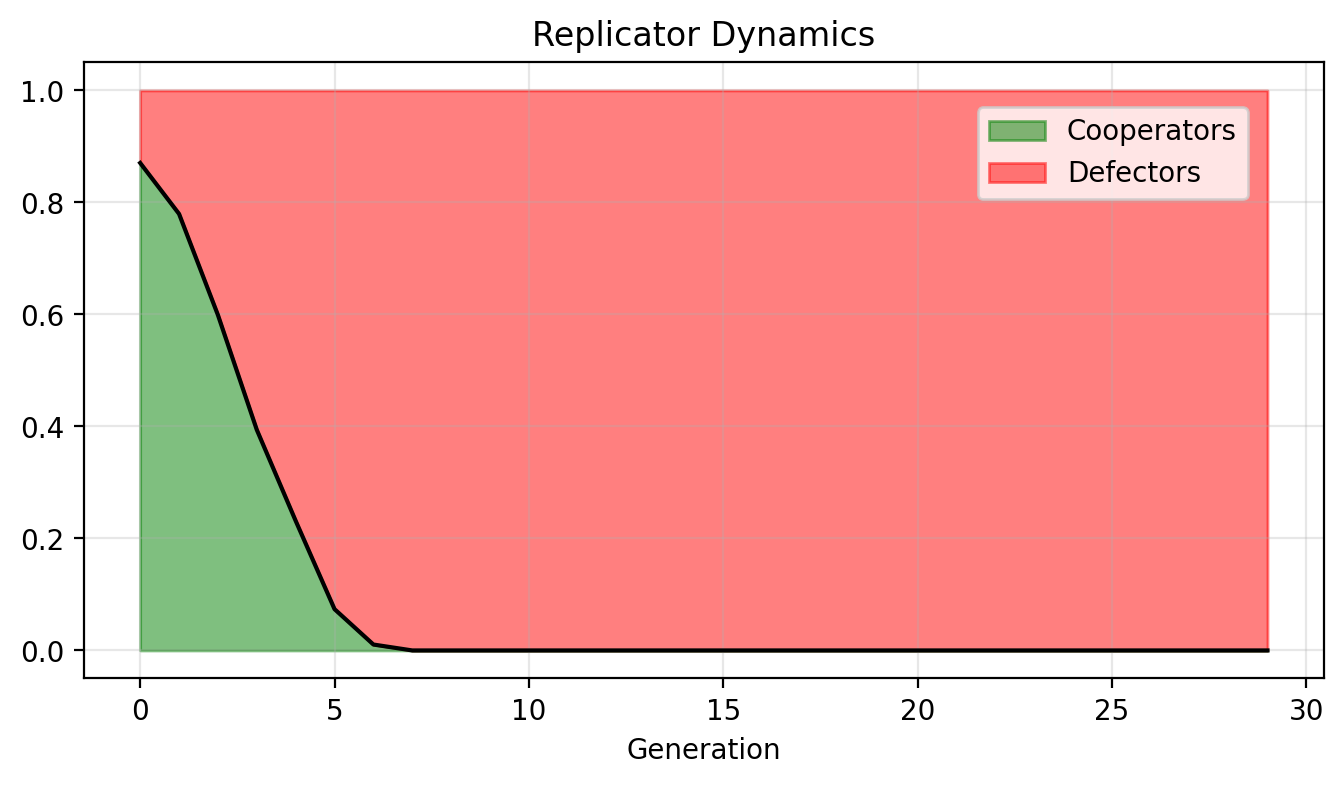

In [ ]:
import matplotlib.pyplot as plt 

xaxis = np.arange(len(x_record))

plt.figure(figsize=(8,4), dpi=200)

plt.plot(xaxis,x_record, color = "black")
plt.fill_between(xaxis,0,x_record, color ="green", alpha = 0.5, label = "Cooperators")
plt.fill_between(xaxis,x_record,1, color = "red", alpha = 0.5, label = "Defectors")

plt.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.xlabel("Generation")
plt.title("Replicator Dynamics")
plt.grid(alpha = 0.3)
plt.show()

## Conclusion

As expected, the proportion of cooperators tends toward zero over many generations x = 0. In a population playing the Prisoner's Dilema, defection is the evolutionarily favoured strategy, leading the population to converge to all defectors.

This is consistent with the game's Nash equilibrium, where no player can improve their payoff by switching from defection to cooperation.

However, what would happen if agent played only with their neighbors instead of the entire population? Would strategy proportions evolve similarly?